Total dataset: 25034 samples
Classes: {'positive': np.int64(12433), 'negative': np.int64(6973), 'neutral': np.int64(5628)}

Training set:   17523 samples
Validation set: 3755 samples
Test set:       3756 samples
TF-IDF features: (17523, 1000)

TF-IDF features: (17523, 1000)

Best C parameter: 3
Best CV F1-Score: 0.7205

Best C parameter: 3
Best CV F1-Score: 0.7205

Training Accuracy: 0.7791

              precision    recall  f1-score   support

    negative       0.75      0.61      0.67      4881
     neutral       0.71      0.85      0.78      3939
    positive       0.83      0.84      0.83      8703

    accuracy                           0.78     17523
   macro avg       0.76      0.77      0.76     17523
weighted avg       0.78      0.78      0.78     17523

Training Accuracy: 0.7791

              precision    recall  f1-score   support

    negative       0.75      0.61      0.67      4881
     neutral       0.71      0.85      0.78      3939
    positive       0.83      0.84 

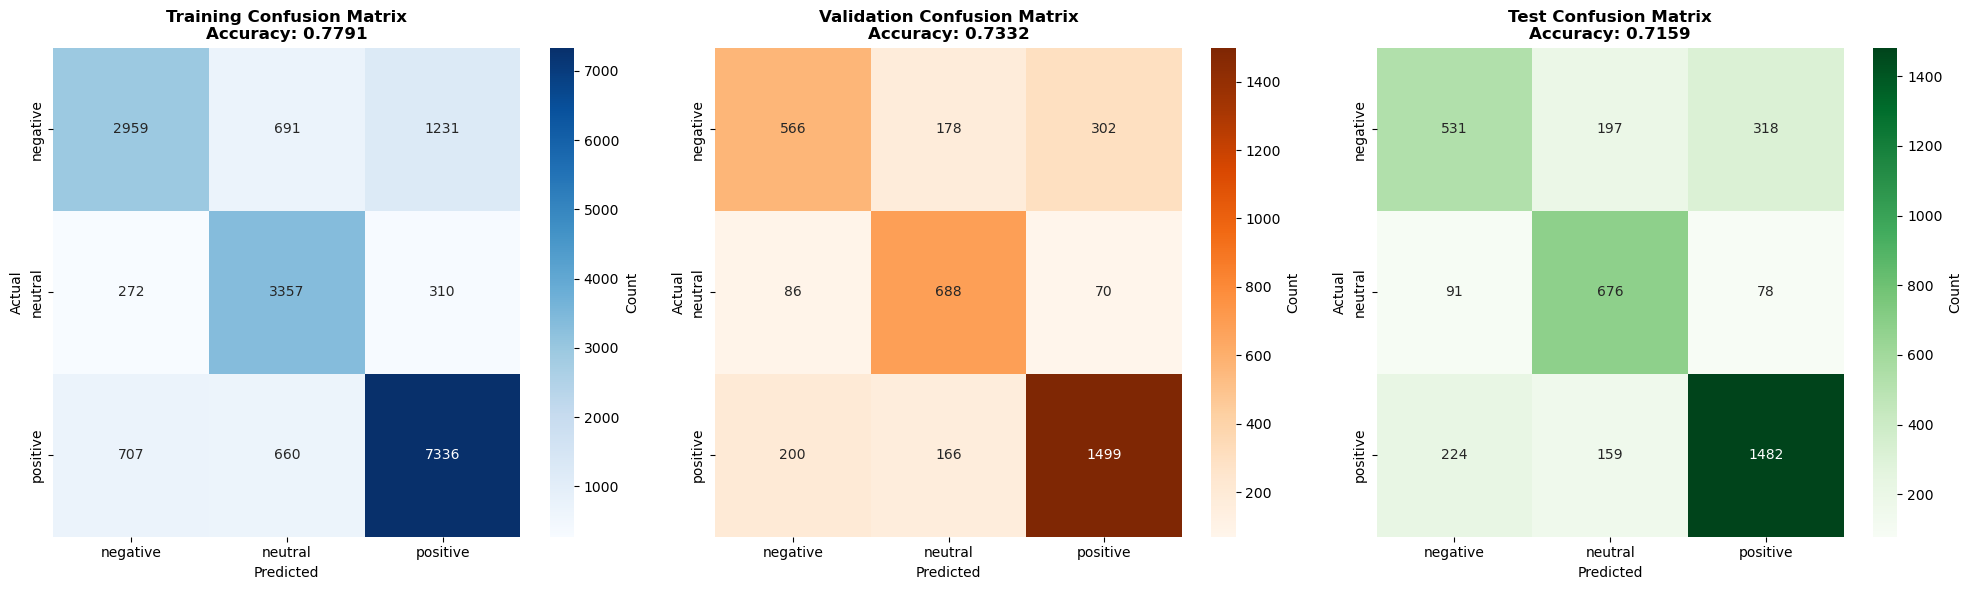

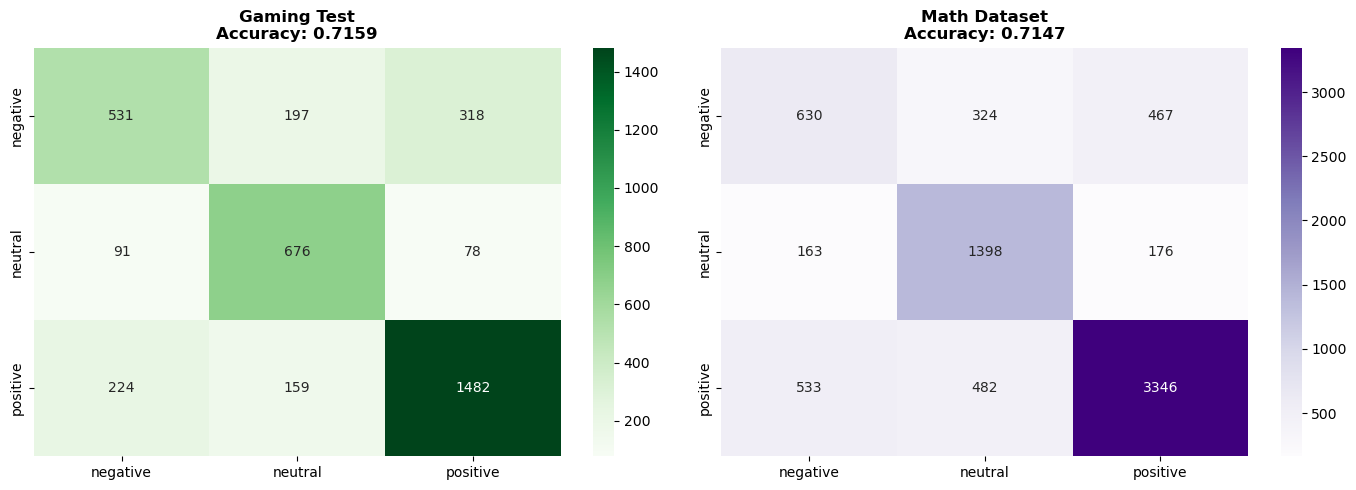

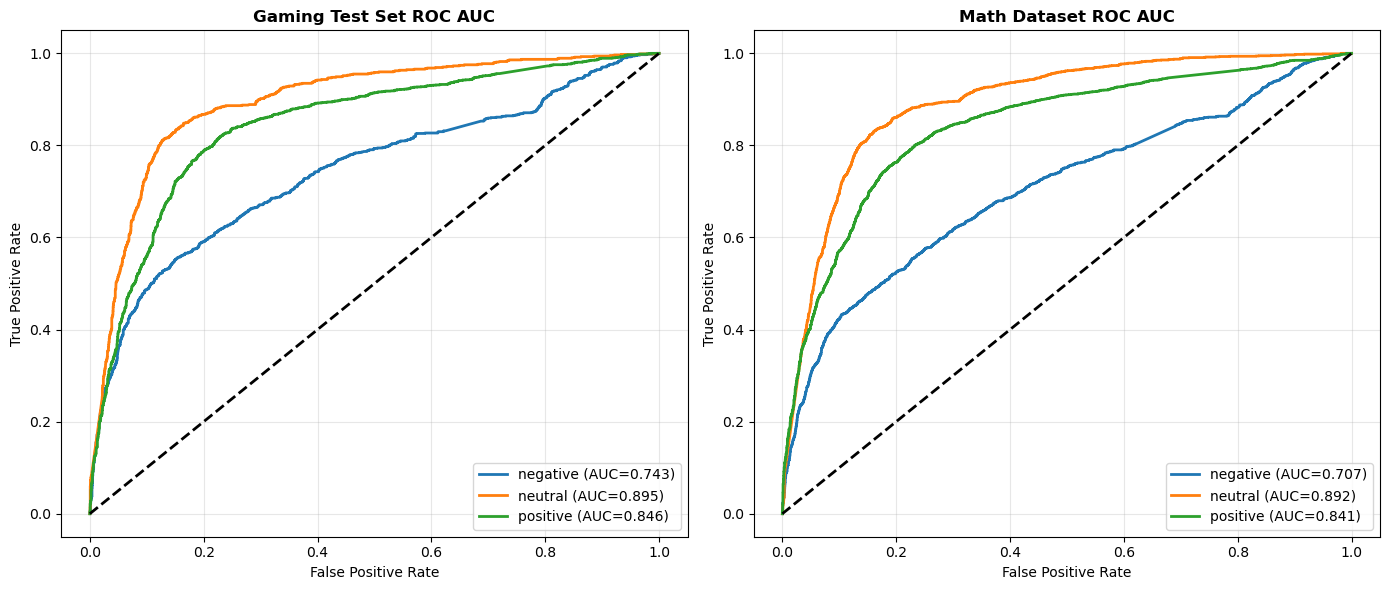

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import LabelEncoder, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import auc, confusion_matrix, classification_report, accuracy_score, roc_curve

# Load gaming comments dataset
df = pd.read_csv('../data/processed/gaming_comments_processed.csv')
df = df.dropna(subset=['comment_text'])

# Creates a new sentiment feature that maps compound values created from VADER to positive, negative, neutral
def label_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'
df['sentiment'] = df['compound'].apply(label_sentiment)

# Makes sure there is >100 values that could be classified
class_counts = df['sentiment'].value_counts()
# df = df[df['sentiment'].isin(class_counts[class_counts > 100].index)]
print(f"Total dataset: {len(df)} samples")
print(f"Classes: {dict(df['sentiment'].value_counts())}\n")

# 70-30 train test split that is stratified to make both sets have same proportions of y values
X_train, X_temp, y_train, y_temp = train_test_split(df['comment_text'], df['sentiment'], test_size=0.30, random_state=42, stratify=df['sentiment'])

# 50-50 validation test split (splits the test set into 15% validation and test set)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)
print(f"Training set:   {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set:       {len(X_test)} samples")

# TF-IDF vectoriation to fit training data
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)
print(f"TF-IDF features: {X_train_vec.shape}\n")

# Use 5-fold cross validation and grid search with a linear kernel 
grid_search = GridSearchCV(
    SVC(kernel='linear', random_state=42),
    {'C': [0.001, 0.01, 0.1, 1.0, 3, 5, 10]},
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1_weighted'
)
grid_search.fit(X_train_vec, y_train)
print(f"Best C parameter: {grid_search.best_params_['C']}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}\n")
model = grid_search.best_estimator_

# Evaluating train model on train set
y_train_pred = model.predict(X_train_vec)
train_accuracy = accuracy_score(y_train, y_train_pred)

all_labels = sorted(np.unique(df['sentiment']))
print(f"Training Accuracy: {train_accuracy:.4f}\n")
print(classification_report(y_train, y_train_pred, labels=all_labels, zero_division=0))

# Evaluating trained model on validation set
y_val_pred = model.predict(X_val_vec)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f}\n")
print(classification_report(y_val, y_val_pred, labels=all_labels, zero_division=0))

# Evaluating trained model on test set
y_test_pred = model.predict(X_test_vec)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Test Accuracy: {test_accuracy:.4f}\n")
print(classification_report(y_test, y_test_pred, labels=all_labels, zero_division=0))

# Confusion matrices for training, validation, and test set to see the performance of our model
cm_train = confusion_matrix(y_train, y_train_pred, labels=all_labels)
cm_val = confusion_matrix(y_val, y_val_pred, labels=all_labels)
cm_test = confusion_matrix(y_test, y_test_pred, labels=all_labels)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Training
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=all_labels, yticklabels=all_labels,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title(f'Training Confusion Matrix\nAccuracy: {train_accuracy:.4f}', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Validation
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges',
            xticklabels=all_labels, yticklabels=all_labels,
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title(f'Validation Confusion Matrix\nAccuracy: {val_accuracy:.4f}', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Test
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=all_labels, yticklabels=all_labels,
            ax=axes[2], cbar_kws={'label': 'Count'})
axes[2].set_title(f'Test Confusion Matrix\nAccuracy: {test_accuracy:.4f}', fontweight='bold')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()


# Test model on a completely different dataset
df_math = pd.read_csv('../data/processed/math_comments_processed.csv')
df_math = df_math.dropna(subset=['comment_text'])
df_math['sentiment'] = df_math['compound'].apply(label_sentiment)

# Vectorize data
X_math_vec = vectorizer.transform(df_math['comment_text'])
y_math = df_math['sentiment'].values

# Predict data
y_math_pred = model.predict(X_math_vec)
math_accuracy = accuracy_score(y_math, y_math_pred)

# Plot confusion matrix 
cm_test = confusion_matrix(y_test, y_test_pred, labels=all_labels)
cm_math = confusion_matrix(y_math, y_math_pred, labels=all_labels)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', xticklabels=all_labels, yticklabels=all_labels, ax=axes[0])
axes[0].set_title(f'Gaming Test\nAccuracy: {test_accuracy:.4f}', fontweight='bold')
sns.heatmap(cm_math, annot=True, fmt='d', cmap='Purples', xticklabels=all_labels, yticklabels=all_labels, ax=axes[1])
axes[1].set_title(f'Math Dataset\nAccuracy: {math_accuracy:.4f}', fontweight='bold')
plt.tight_layout()
plt.show()

# ROC AUC curve
encoder = LabelEncoder()
y_test_enc = encoder.fit_transform(y_test)
y_math_enc = encoder.transform(y_math)

y_test_scores = model.decision_function(X_test_vec)
y_math_scores = model.decision_function(X_math_vec)

y_test_bin = label_binarize(y_test_enc, classes=[0, 1, 2])
y_math_bin = label_binarize(y_math_enc, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gaming ROC
for i, label in enumerate(all_labels):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_scores[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2, label=f'{label} (AUC={roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=2)
axes[0].set_title('Gaming Test Set ROC AUC', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Math ROC
for i, label in enumerate(all_labels):
    fpr, tpr, _ = roc_curve(y_math_bin[:, i], y_math_scores[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, lw=2, label=f'{label} (AUC={roc_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1].set_title('Math Dataset ROC AUC', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
